In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/merged/dataset_zone_1.csv")
df.head()

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total
0,2025-02-09 00:00:00,NaN,NaN,NaN,NaN,5.7775,91.0,0.0,1025.785000,5.960000,0.0,7.670000,10.785000,NaN,NaN,NaN,0,0.0
1,2025-02-09 00:10:00,NaN,NaN,NaN,NaN,5.7275,91.0,0.0,1025.751667,6.093333,0.0,7.603333,10.751667,NaN,NaN,NaN,0,0.0
2,2025-02-09 00:20:00,NaN,NaN,NaN,NaN,5.6775,91.0,0.0,1025.718333,6.226667,0.0,7.536667,10.718333,NaN,NaN,NaN,0,0.0
3,2025-02-09 00:30:00,NaN,NaN,NaN,NaN,5.6275,91.0,0.0,1025.685000,6.360000,0.0,7.470000,10.685000,NaN,NaN,NaN,0,0.0
4,2025-02-09 00:40:00,NaN,NaN,NaN,NaN,5.5775,91.0,0.0,1025.651667,6.493333,0.0,7.403333,10.651667,NaN,NaN,NaN,0,0.0


In [3]:
df.shape


(33259, 18)

In [4]:
df.columns

Index(['ts', 'outside_temperature', 'inside_temperature', 'outside_humidity',
       'inside_humidity', 'weather_temp', 'weather_humidity', 'weather_rain',
       'weather_pressure', 'weather_wind_speed', 'weather_radiation',
       'soil_temperature_0-7cm', 'soil_temperature_7-18cm', 'ec', 'ph',
       'soil_moisture', 'irrigation_duration_minutes', 'liters_total'],
      dtype='str')

In [5]:
df.dtypes

ts                                 str
outside_temperature            float64
inside_temperature             float64
outside_humidity               float64
inside_humidity                float64
weather_temp                   float64
weather_humidity               float64
weather_rain                   float64
weather_pressure               float64
weather_wind_speed             float64
weather_radiation              float64
soil_temperature_0-7cm         float64
soil_temperature_7-18cm        float64
ec                             float64
ph                             float64
soil_moisture                  float64
irrigation_duration_minutes      int64
liters_total                   float64
dtype: object

In [6]:
df.isna().sum()

ts                                 0
outside_temperature            31174
inside_temperature             24316
outside_humidity               31167
inside_humidity                24317
weather_temp                       0
weather_humidity                   0
weather_rain                       0
weather_pressure                   0
weather_wind_speed                 0
weather_radiation                  0
soil_temperature_0-7cm             0
soil_temperature_7-18cm            0
ec                             18177
ph                              5701
soil_moisture                  22516
irrigation_duration_minutes        0
liters_total                       0
dtype: int64

In [7]:
df.isna().mean()*100

ts                              0.000000
outside_temperature            93.731020
inside_temperature             73.111038
outside_humidity               93.709973
inside_humidity                73.114044
weather_temp                    0.000000
weather_humidity                0.000000
weather_rain                    0.000000
weather_pressure                0.000000
weather_wind_speed              0.000000
weather_radiation               0.000000
soil_temperature_0-7cm          0.000000
soil_temperature_7-18cm         0.000000
ec                             54.652876
ph                             17.141225
soil_moisture                  67.698969
irrigation_duration_minutes     0.000000
liters_total                    0.000000
dtype: float64

In [8]:
df["irrigation_duration_minutes"].value_counts()

irrigation_duration_minutes
0     32541
10      558
7        32
9        30
1        20
8        18
6        15
2        12
4        11
3        11
5        11
Name: count, dtype: int64

In [9]:
(df["irrigation_duration_minutes"] > 0).value_counts()

irrigation_duration_minutes
False    32541
True       718
Name: count, dtype: int64

In [10]:
df[df["irrigation_duration_minutes"] > 0][
    ["ts", "irrigation_duration_minutes", "liters_total"]
].head(20)

,ts,irrigation_duration_minutes,liters_total
1908,2025-02-22 06:00:00,9,9.9
1909,2025-02-22 06:10:00,7,7.7
3411,2025-03-04 16:30:00,8,8.8
3412,2025-03-04 16:40:00,10,11.0
3413,2025-03-04 16:50:00,10,11.0
3414,2025-03-04 17:00:00,10,11.0
3415,2025-03-04 17:10:00,10,11.0
3416,2025-03-04 17:20:00,10,11.0
3417,2025-03-04 17:30:00,10,11.0
3418,2025-03-04 17:40:00,10,11.0


In [11]:
events = pd.read_csv("../data/irrigation_events/final_irrigation_events.csv")
events.head()

,sector,start,end,initial_humidity,final_humidity,stop_reason,type,duration_hours
0,1,2025-02-22 06:01:00,2025-02-22 06:16:00,28,28,fertigation_timeout,fertigation,0.25
1,1,2025-03-04 16:32:00,2025-03-04 18:00:00,46,46,time_restriction,standard_irrigation,1.47
2,1,2025-03-10 15:58:00,2025-03-10 16:33:00,44,41,physical_valve_closure,standard_irrigation,0.58
3,1,2025-04-07 06:07:00,2025-04-07 06:28:00,44,41,fertigation_timeout,fertigation,0.35
4,1,2025-04-11 06:01:00,2025-04-11 06:16:00,42,39,fertigation_timeout,fertigation,0.25


In [12]:
events.shape

(789, 8)

In [13]:
events.dtypes

sector                int64
start                   str
end                     str
initial_humidity      int64
final_humidity        int64
stop_reason             str
type                    str
duration_hours      float64
dtype: object

In [14]:
events.columns

Index(['sector', 'start', 'end', 'initial_humidity', 'final_humidity',
       'stop_reason', 'type', 'duration_hours'],
      dtype='str')

In [15]:
events_zone1 = events[events["sector"]== 1]
events_zone1.shape

(87, 8)

In [16]:
events_zone1["type"].value_counts()

type
standard_irrigation    45
fertigation            42
Name: count, dtype: int64

In [17]:
events_zone1["stop_reason"].value_counts()

stop_reason
fertigation_timeout       45
physical_valve_closure    24
time_restriction          10
humidity_threshold         8
Name: count, dtype: int64

In [18]:
events_zone1 = events_zone1.copy()

In [19]:
events_zone1["start"]= pd.to_datetime(events_zone1["start"])
events_zone1["end"] = pd.to_datetime(events_zone1["end"])

In [20]:
events_zone1.dtypes

sector                       int64
start               datetime64[us]
end                 datetime64[us]
initial_humidity             int64
final_humidity               int64
stop_reason                    str
type                           str
duration_hours             float64
dtype: object

In [21]:
standard_events = events_zone1[events_zone1["type"]== "standard_irrigation"].copy()
standard_events.shape

(45, 8)

In [22]:
standard_events["date"] = standard_events["start"].dt.date

In [23]:
daily_events = standard_events.groupby("date").size()
daily_events.head(10)

date
2025-03-04    1
2025-03-10    1
2025-04-13    1
2025-04-17    2
2025-05-07    1
2025-05-09    1
2025-05-10    1
2025-05-12    1
2025-05-14    1
2025-05-15    1
dtype: int64

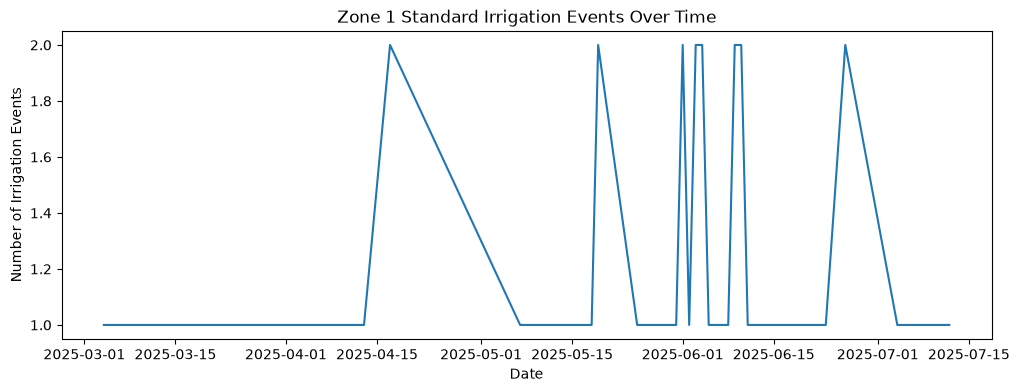

In [24]:
import matplotlib.pyplot as plt
daily_events.plot(figsize=(12,4))

plt.title("Zone 1 Standard Irrigation Events Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Irrigation Events")
plt.show()

In [25]:
df["ts"] = pd.to_datetime(df["ts"])

In [26]:
df["ts"].dtype

dtype('<M8[us]')

In [27]:
df["date"] = df["ts"].dt.date
df[["ts","date"]].head()

,ts,date
0,2025-02-09 00:00:00,2025-02-09
1,2025-02-09 00:10:00,2025-02-09
2,2025-02-09 00:20:00,2025-02-09
3,2025-02-09 00:30:00,2025-02-09
4,2025-02-09 00:40:00,2025-02-09


In [28]:
daily_weather = df.groupby("date").agg({
    "weather_temp": "mean",
    "weather_humidity": "mean",
    "weather_rain": "sum",
    "weather_pressure": "mean",
    "weather_wind_speed": "mean",
    "weather_radiation": "mean"
})

daily_weather.head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation
date,,,,,,
2025-02-09,8.608125,76.898264,0.0,1024.013403,4.921597,72.791667
2025-02-10,7.906563,77.788194,0.0,1022.298090,4.058264,111.958333
2025-02-11,8.020903,87.852431,11.4,1022.079444,4.430590,85.541667
2025-02-12,9.515347,88.647569,2.4,1020.856979,10.780313,18.000000
2025-02-13,10.639757,90.894097,7.2,1016.710208,10.951840,55.416667


In [29]:
daily_weather.shape


(231, 6)

In [30]:
standard_events.head()

,sector,start,end,initial_humidity,final_humidity,stop_reason,type,duration_hours,date
1,1,2025-03-04 16:32:00,2025-03-04 18:00:00,46,46,time_restriction,standard_irrigation,1.47,2025-03-04
2,1,2025-03-10 15:58:00,2025-03-10 16:33:00,44,41,physical_valve_closure,standard_irrigation,0.58,2025-03-10
5,1,2025-04-13 13:14:00,2025-04-13 18:00:00,53,52,time_restriction,standard_irrigation,4.77,2025-04-13
6,1,2025-04-17 09:09:00,2025-04-17 13:15:00,40,22,physical_valve_closure,standard_irrigation,4.10,2025-04-17
7,1,2025-04-17 13:26:00,2025-04-17 18:00:00,22,60,time_restriction,standard_irrigation,4.57,2025-04-17


In [31]:
irrigation_dates = standard_events["start"].dt.date.unique()

In [32]:
daily_weather["irrigation_today"] = (
    daily_weather.index.isin(irrigation_dates)
).astype(int)
# isin = is in?     astype = as type (transfer data type into int)
# if true, 1; if false, 0

In [33]:
daily_weather[daily_weather["irrigation_today"] == 1].head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,irrigation_today
date,,,,,,,
2025-03-04,10.792153,66.140625,0.0,1019.699514,11.505972,155.791667,1
2025-03-10,14.611250,85.584028,0.6,1010.561007,20.646319,64.500000,1
2025-04-13,14.983924,71.028125,3.6,1014.982708,9.573438,67.541667,1
2025-04-17,17.542778,67.805208,25.8,1009.966528,22.721076,16.083333,1
2025-05-07,21.168229,58.571181,0.0,1008.637639,9.127847,219.625000,1


In [34]:
daily_weather["irrigation_next_day"] = (
    daily_weather["irrigation_today"].shift(-1)
)
#.shift(-1) means that the value of the next day will be assigned to the current day. This is because we want to predict whether there will be irrigation tomorrow based on today's weather data.

In [35]:
daily_weather[
    ["irrigation_today", "irrigation_next_day"]
].head(30)

,irrigation_today,irrigation_next_day
date,,
2025-02-09,0,0.0
2025-02-10,0,0.0
2025-02-11,0,0.0
2025-02-12,0,0.0
2025-02-13,0,0.0
2025-02-14,0,0.0
2025-02-15,0,0.0
2025-02-16,0,0.0
2025-02-17,0,0.0


In [36]:
standard_events[["start", "date"]].head(10)

,start,date
1,2025-03-04 16:32:00,2025-03-04
2,2025-03-10 15:58:00,2025-03-10
5,2025-04-13 13:14:00,2025-04-13
6,2025-04-17 09:09:00,2025-04-17
7,2025-04-17 13:26:00,2025-04-17
9,2025-05-07 07:15:00,2025-05-07
14,2025-05-09 06:50:00,2025-05-09
15,2025-05-10 16:14:00,2025-05-10
18,2025-05-12 06:40:00,2025-05-12
20,2025-05-14 06:08:00,2025-05-14


In [37]:
irrigation_dates[:10]

array([datetime.date(2025, 3, 4), datetime.date(2025, 3, 10),
       datetime.date(2025, 4, 13), datetime.date(2025, 4, 17),
       datetime.date(2025, 5, 7), datetime.date(2025, 5, 9),
       datetime.date(2025, 5, 10), datetime.date(2025, 5, 12),
       datetime.date(2025, 5, 14), datetime.date(2025, 5, 15)],
      dtype=object)

In [38]:
print(daily_weather.index[20:30])

print(irrigation_dates[:3])



Index([2025-03-01, 2025-03-02, 2025-03-03, 2025-03-04, 2025-03-05, 2025-03-06,
       2025-03-07, 2025-03-08, 2025-03-09, 2025-03-10],
      dtype='object', name='date')
[datetime.date(2025, 3, 4) datetime.date(2025, 3, 10)
 datetime.date(2025, 4, 13)]


In [39]:
daily_weather.loc[
    daily_weather.index.isin(irrigation_dates),
    ["irrigation_today"]
].head(10)


,irrigation_today
date,
2025-03-04,1
2025-03-10,1
2025-04-13,1
2025-04-17,1
2025-05-07,1
2025-05-09,1
2025-05-10,1
2025-05-12,1
2025-05-14,1


In [40]:
daily_weather["irrigation_next_day"].value_counts()

irrigation_next_day
0.0    193
1.0     37
Name: count, dtype: int64

In [41]:
daily_weather["irrigation_next_day"].value_counts(normalize= True)*100

irrigation_next_day
0.0    83.913043
1.0    16.086957
Name: proportion, dtype: float64

In [42]:
X_low = daily_weather[["weather_temp",
"weather_humidity",
"weather_rain",
"weather_pressure",
"weather_wind_speed",
"weather_radiation"]]
X_low.head(5)

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation
date,,,,,,
2025-02-09,8.608125,76.898264,0.0,1024.013403,4.921597,72.791667
2025-02-10,7.906563,77.788194,0.0,1022.298090,4.058264,111.958333
2025-02-11,8.020903,87.852431,11.4,1022.079444,4.430590,85.541667
2025-02-12,9.515347,88.647569,2.4,1020.856979,10.780313,18.000000
2025-02-13,10.639757,90.894097,7.2,1016.710208,10.951840,55.416667


In [43]:
daily_weather.head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,irrigation_today,irrigation_next_day
date,,,,,,,,
2025-02-09,8.608125,76.898264,0.0,1024.013403,4.921597,72.791667,0,0.0
2025-02-10,7.906563,77.788194,0.0,1022.298090,4.058264,111.958333,0,0.0
2025-02-11,8.020903,87.852431,11.4,1022.079444,4.430590,85.541667,0,0.0
2025-02-12,9.515347,88.647569,2.4,1020.856979,10.780313,18.000000,0,0.0
2025-02-13,10.639757,90.894097,7.2,1016.710208,10.951840,55.416667,0,0.0


In [44]:
y = daily_weather["irrigation_next_day"]
y.head(5)

date
2025-02-09    0.0
2025-02-10    0.0
2025-02-11    0.0
2025-02-12    0.0
2025-02-13    0.0
Name: irrigation_next_day, dtype: float64

# drop missing values -- .dropna()
# is not nan -- .notna()

日期          X_low          y
--------------------------------
Day 1          X            0
Day 2          X            0
...
Day 230        X            1
Day 231        X           NaN



In [45]:
valid_rows = y.notna()
X_low = X_low.loc[valid_rows]
y = y.loc[valid_rows]

In [46]:
valid_rows = y.notna()
X_low.shape
valid_rows.value_counts()

irrigation_next_day
True    230
Name: count, dtype: int64

In [47]:
print(y.shape)
print(y.isna().sum())
print(valid_rows.value_counts())

(230,)
0
irrigation_next_day
True    230
Name: count, dtype: int64


In [48]:
print(X_low.shape)
print(y.shape)

(230, 6)
(230,)


## Train/ Test Spilt

In [49]:
split_index = int(len(X_low)*0.8)
# split_index = int(len(X_low)*0.8) means that we are splitting the data into 80% training and 20% testing. The split_index is the index where we will split the data.

In [50]:
X_train = X_low.iloc[:184]
X_test  = X_low.iloc[184:]
#.loc   → 根据 label（标签/名字）选
#.iloc  → 根据 integer position（整数位置）选

In [51]:
y_train = y.iloc[:184]
y_test  = y.iloc[184:]

In [52]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(184, 6)
(46, 6)
(184,)
(46,)


### Baseline Model

In [53]:
y_test.value_counts()


irrigation_next_day
0.0    46
Name: count, dtype: int64

In [54]:
## boolean mask (布尔值筛筛选条件）。data[condition]  → 选出满足条件的行
y[y == 1].tail(10)


date
2025-06-15    1.0
2025-06-16    1.0
2025-06-17    1.0
2025-06-21    1.0
2025-06-22    1.0
2025-06-25    1.0
2025-07-03    1.0
2025-07-05    1.0
2025-07-08    1.0
2025-07-11    1.0
Name: irrigation_next_day, dtype: float64

X-low是dataframe 二维数据表
y是 series 一维数据
index 是索引

dataframe 通常是features 作为x series通常是target 作为y


In [55]:
y.index

Index([2025-02-09, 2025-02-10, 2025-02-11, 2025-02-12, 2025-02-13, 2025-02-14,
       2025-02-15, 2025-02-16, 2025-02-17, 2025-02-18,
       ...
       2025-09-17, 2025-09-18, 2025-09-19, 2025-09-20, 2025-09-21, 2025-09-22,
       2025-09-23, 2025-09-24, 2025-09-25, 2025-09-26],
      dtype='object', name='date', length=230)

In [56]:
#把dtype从object转成datetime
y.index = pd.to_datetime(y.index)
y.index

DatetimeIndex(['2025-02-09', '2025-02-10', '2025-02-11', '2025-02-12',
               '2025-02-13', '2025-02-14', '2025-02-15', '2025-02-16',
               '2025-02-17', '2025-02-18',
               ...
               '2025-09-17', '2025-09-18', '2025-09-19', '2025-09-20',
               '2025-09-21', '2025-09-22', '2025-09-23', '2025-09-24',
               '2025-09-25', '2025-09-26'],
              dtype='datetime64[s]', name='date', length=230, freq=None)

In [57]:
#提取所有y==1 的月份
y[y==1].index.month

Index([3, 3, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7],
      dtype='int32', name='date')

In [58]:
#统计1出现次数
y[y==1].index.month.value_counts()

date
6    18
5    11
7     4
3     2
4     2
Name: count, dtype: int64

In [59]:
events_after_july11 = events_zone1[
    events_zone1["start"] > "2025-07-11"
]
events_after_july11.shape
events_after_july11.head()

,sector,start,end,initial_humidity,final_humidity,stop_reason,type,duration_hours
83,1,2025-07-11 06:01:00,2025-07-11 06:16:00,42,39,fertigation_timeout,fertigation,0.25
84,1,2025-07-12 06:01:00,2025-07-12 06:16:00,31,36,fertigation_timeout,fertigation,0.25
85,1,2025-07-12 16:02:00,2025-07-12 16:27:00,41,78,fertigation_timeout,standard_irrigation,0.42
86,1,2025-07-13 09:02:00,2025-07-13 09:17:00,70,64,fertigation_timeout,fertigation,0.25


In [60]:
events_after_july11.tail()

,sector,start,end,initial_humidity,final_humidity,stop_reason,type,duration_hours
83,1,2025-07-11 06:01:00,2025-07-11 06:16:00,42,39,fertigation_timeout,fertigation,0.25
84,1,2025-07-12 06:01:00,2025-07-12 06:16:00,31,36,fertigation_timeout,fertigation,0.25
85,1,2025-07-12 16:02:00,2025-07-12 16:27:00,41,78,fertigation_timeout,standard_irrigation,0.42
86,1,2025-07-13 09:02:00,2025-07-13 09:17:00,70,64,fertigation_timeout,fertigation,0.25


In [61]:
events_zone1["start"].max()

Timestamp('2025-07-13 09:02:00')

In [62]:
df.head()

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total,date
0,2025-02-09 00:00:00,NaN,NaN,NaN,NaN,5.7775,91.0,0.0,1025.785000,5.960000,0.0,7.670000,10.785000,NaN,NaN,NaN,0,0.0,2025-02-09
1,2025-02-09 00:10:00,NaN,NaN,NaN,NaN,5.7275,91.0,0.0,1025.751667,6.093333,0.0,7.603333,10.751667,NaN,NaN,NaN,0,0.0,2025-02-09
2,2025-02-09 00:20:00,NaN,NaN,NaN,NaN,5.6775,91.0,0.0,1025.718333,6.226667,0.0,7.536667,10.718333,NaN,NaN,NaN,0,0.0,2025-02-09
3,2025-02-09 00:30:00,NaN,NaN,NaN,NaN,5.6275,91.0,0.0,1025.685000,6.360000,0.0,7.470000,10.685000,NaN,NaN,NaN,0,0.0,2025-02-09
4,2025-02-09 00:40:00,NaN,NaN,NaN,NaN,5.5775,91.0,0.0,1025.651667,6.493333,0.0,7.403333,10.651667,NaN,NaN,NaN,0,0.0,2025-02-09


In [63]:
df[df["liters_total"]>0].head()
#布尔值筛选  取出 liters_total 这一列。问每一行：“这一行的灌溉水量是否大于 0？” → 得到一串 True / False。

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total,date
1908,2025-02-22 06:00:00,NaN,NaN,NaN,NaN,1.077500,95.000000,0.0,1026.415000,2.400,0.000000,3.185000,7.892500,NaN,NaN,NaN,9,9.9,2025-02-22
1909,2025-02-22 06:10:00,NaN,NaN,NaN,NaN,1.027500,95.000000,0.0,1026.448333,2.400,0.000000,3.151667,7.875833,NaN,NaN,NaN,7,7.7,2025-02-22
3411,2025-03-04 16:30:00,NaN,NaN,NaN,NaN,13.440000,51.875000,0.0,1019.285000,12.455,322.900000,14.312500,11.415000,320.0,6.9,46.0,8,8.8,2025-03-04
3412,2025-03-04 16:40:00,NaN,NaN,NaN,NaN,13.306667,52.708333,0.0,1019.251667,12.355,298.233333,14.229167,11.448333,NaN,6.7,NaN,10,11.0,2025-03-04
3413,2025-03-04 16:50:00,NaN,NaN,NaN,NaN,13.173333,53.541667,0.0,1019.218333,12.255,273.566667,14.145833,11.481667,NaN,6.7,NaN,10,11.0,2025-03-04


In [64]:
df[
    (df["ts"] > "2025-07-13") &
    (df["liters_total"] > 0)
].head(5)

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total,date
22230,2025-07-13 09:00:00,NaN,NaN,NaN,NaN,28.065000,36.250000,0.0,1014.085000,0.282500,378.375,25.8475,27.0,393.0,7.2,70.0,8,8.8,2025-07-13
22231,2025-07-13 09:10:00,NaN,NaN,NaN,NaN,28.431667,34.583333,0.0,1014.051667,0.465833,405.875,26.3975,27.0,386.0,7.0,64.0,8,8.8,2025-07-13


In [65]:
df[
    (df["ts"] > "2025-07-13 09:17:00") &
    (df["liters_total"] > 0)
]

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total,date


In [66]:
df.head()

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total,date
0,2025-02-09 00:00:00,NaN,NaN,NaN,NaN,5.7775,91.0,0.0,1025.785000,5.960000,0.0,7.670000,10.785000,NaN,NaN,NaN,0,0.0,2025-02-09
1,2025-02-09 00:10:00,NaN,NaN,NaN,NaN,5.7275,91.0,0.0,1025.751667,6.093333,0.0,7.603333,10.751667,NaN,NaN,NaN,0,0.0,2025-02-09
2,2025-02-09 00:20:00,NaN,NaN,NaN,NaN,5.6775,91.0,0.0,1025.718333,6.226667,0.0,7.536667,10.718333,NaN,NaN,NaN,0,0.0,2025-02-09
3,2025-02-09 00:30:00,NaN,NaN,NaN,NaN,5.6275,91.0,0.0,1025.685000,6.360000,0.0,7.470000,10.685000,NaN,NaN,NaN,0,0.0,2025-02-09
4,2025-02-09 00:40:00,NaN,NaN,NaN,NaN,5.5775,91.0,0.0,1025.651667,6.493333,0.0,7.403333,10.651667,NaN,NaN,NaN,0,0.0,2025-02-09


In [67]:
#c从datetime中提取出月份
df["month"] = df["ts"].dt.month
df.head()

,ts,outside_temperature,inside_temperature,outside_humidity,inside_humidity,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,soil_temperature_0-7cm,soil_temperature_7-18cm,ec,ph,soil_moisture,irrigation_duration_minutes,liters_total,date,month
0,2025-02-09 00:00:00,NaN,NaN,NaN,NaN,5.7775,91.0,0.0,1025.785000,5.960000,0.0,7.670000,10.785000,NaN,NaN,NaN,0,0.0,2025-02-09,2
1,2025-02-09 00:10:00,NaN,NaN,NaN,NaN,5.7275,91.0,0.0,1025.751667,6.093333,0.0,7.603333,10.751667,NaN,NaN,NaN,0,0.0,2025-02-09,2
2,2025-02-09 00:20:00,NaN,NaN,NaN,NaN,5.6775,91.0,0.0,1025.718333,6.226667,0.0,7.536667,10.718333,NaN,NaN,NaN,0,0.0,2025-02-09,2
3,2025-02-09 00:30:00,NaN,NaN,NaN,NaN,5.6275,91.0,0.0,1025.685000,6.360000,0.0,7.470000,10.685000,NaN,NaN,NaN,0,0.0,2025-02-09,2
4,2025-02-09 00:40:00,NaN,NaN,NaN,NaN,5.5775,91.0,0.0,1025.651667,6.493333,0.0,7.403333,10.651667,NaN,NaN,NaN,0,0.0,2025-02-09,2


In [68]:
df[["ts","liters_total","month"]].head()
#取多个columns，传入一个list，list里放列名。  df[["ts","liters_total","month"]]  → 取出 ts、liters_total、month 三列。

,ts,liters_total,month
0,2025-02-09 00:00:00,0.0,2
1,2025-02-09 00:10:00,0.0,2
2,2025-02-09 00:20:00,0.0,2
3,2025-02-09 00:30:00,0.0,2
4,2025-02-09 00:40:00,0.0,2


In [69]:
df[
    df["liters_total"] > 0
][["ts", "liters_total", "month"]].head()

,ts,liters_total,month
1908,2025-02-22 06:00:00,9.9,2
1909,2025-02-22 06:10:00,7.7,2
3411,2025-03-04 16:30:00,8.8,3
3412,2025-03-04 16:40:00,11.0,3
3413,2025-03-04 16:50:00,11.0,3


知识点summary
df["liters_total"] > 0
        ↓
Boolean Mask 🔴
        ↓
df[mask]
筛选 rows 🔴
        ↓
[["ts", "liters_total", "month"]]
选择多个 columns 🔴
        ↓
.head()
前 5 行 🔴

80/20 chronological split
        ↓
发现 y_test = 46 个 0，完全没有 1
        ↓
为什么后期没有 irrigation？
        ↓
检查 events_zone1
        ↓
Zone 1 最后一条 irrigation event：
2025-07-13 09:02–09:17
        ↓
再检查原始 df 的 liters_total
        ↓
07-13 09:17 后确实没有 liters_total > 0
        ↓
README：
整个农场其他 sectors 的 irrigation 一直存在到 Aug 31
        ↓
所以不是整个 irrigation 数据源坏了
但 README 没解释为什么 Zone 1 停止 irrigation
        ↓
⚠️ 不能擅自说“后面不需要灌溉”，现在开始做EDA：Zone 1 在 7 月前后到底发生了什么变化？后面的 0 能不能作为正常 negative samples（负样本）使用？

In [70]:
#Zone 1 从 February → September，每个月总共用了多少 irrigation water？
#groupby()  → 先按月份分组，再对每组的 liters_total 求和
monthly_water = df.groupby("month")["liters_total"].sum()
monthly_water
#把 df 按照月份 month 分组，在每个月中取出 liters_total，把它们全部加起来，并把结果保存到 monthly_water。

month
2      17.6
3     137.5
4     931.7
5    2299.0
6    3269.2
7     477.4
8       0.0
9       0.0
Name: liters_total, dtype: float64

Irrigation
    ↓
7 月突然下降，8–9 月 = 0
    ↓
Rainfall 有没有明显增加？
    ↓
Soil moisture 有没有明显变化？
    ↓
Sensor availability 有没有发生变化？
    ↓
综合判断后期是不是和前期处于不同 data regime

# EDA 探索性数据分析与数据质量评估

### 因素一：rian fall

In [71]:
monthly_rain = df.groupby("month")["weather_rain"].sum()

In [72]:
daily_weather.head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,irrigation_today,irrigation_next_day
date,,,,,,,,
2025-02-09,8.608125,76.898264,0.0,1024.013403,4.921597,72.791667,0,0.0
2025-02-10,7.906563,77.788194,0.0,1022.298090,4.058264,111.958333,0,0.0
2025-02-11,8.020903,87.852431,11.4,1022.079444,4.430590,85.541667,0,0.0
2025-02-12,9.515347,88.647569,2.4,1020.856979,10.780313,18.000000,0,0.0
2025-02-13,10.639757,90.894097,7.2,1016.710208,10.951840,55.416667,0,0.0


In [73]:
type(daily_weather.index)

pandas.Index

In [74]:
daily_weather.index = pd.to_datetime(daily_weather.index)
#改变daliy_weather的index的数据类型为datetime64[ns]，以便后续进行时间序列分析。
type(daily_weather.index)

pandas.DatetimeIndex

In [75]:
daily_weather["month"] = daily_weather.index.month
## 从 daily_weather 的日期索引中提取月份，并创建新的 month 列。
daily_weather[["weather_rain", "month"]].head()


,weather_rain,month
date,,
2025-02-09,0.0,2
2025-02-10,0.0,2
2025-02-11,11.4,2
2025-02-12,2.4,2
2025-02-13,7.2,2


In [76]:
monthly_rain = daily_weather.groupby("month")["weather_rain"].sum()
monthly_rain
## 查看计算得到的每月总降雨量，观察不同月份 rainfall 的变化。

month
2    258.0
3    544.2
4    333.6
5    274.2
6     10.8
7     13.8
8    250.8
9     73.8
Name: weather_rain, dtype: float64

### 因素二： soil moisture

我们已经查了
Irrigation
    ↓
Rainfall
    ↓
接下来：
Soil Moisture

问题：大约三分之二的数据是 missing values（缺失值）。
研究方向：
① 每个月 soil moisture 平均是多少？
② 每个月到底有多少 soil moisture 数据？


In [77]:
df[["ts", "soil_moisture", "month"]].head()

,ts,soil_moisture,month
0,2025-02-09 00:00:00,NaN,2
1,2025-02-09 00:10:00,NaN,2
2,2025-02-09 00:20:00,NaN,2
3,2025-02-09 00:30:00,NaN,2
4,2025-02-09 00:40:00,NaN,2


In [78]:
df["soil_moisture"].notna().head(10)

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: soil_moisture, dtype: bool

df
↓
按 month 分组
↓
每个月选择 soil_moisture
↓
检查每个值是不是非 NaN
↓
True = 1，False = 0
↓
计算平均值
↓
× 100
↓
得到百分比


lambda x: x.notna().mean() * 100
理解成：
“对于每个月这一组 soil moisture 数据 x，执行后面的计算。”


In [79]:
monthly_soil_availability = df.groupby("month")["soil_moisture"].apply(
    lambda x: x.notna().mean() * 100
)
monthly_soil_availability
## 查看 February 到 September 每个月 soil_moisture 传感器数据的可用率。

month
2     2.812500
3     3.696237
4     3.888889
5     7.773297
6    24.606481
7    34.879032
8    91.196237
9    84.754056
Name: soil_moisture, dtype: float64

每个月有效 soil_moisture 的 median 是多少？
先看 monthly median（每月中位数）。
soil moisture sensor data 可能存在异常值/outliers（离群值）


In [80]:
monthly_soil_median = df.groupby("month")["soil_moisture"].median()
monthly_soil_median
## 按月份对 soil_moisture 进行分组，并计算每个月土壤湿度的中位数，减少异常值对结果的影响。
#8–9 月 sensor availability 很高，但 soil moisture values 本身可能发生了明显的 distribution shift（分布变化）或异常编码。

month
2    50.0
3    47.0
4    47.0
5    47.0
6    51.0
7    24.0
8    21.0
9   -20.0
Name: soil_moisture, dtype: float64

In [81]:
df[df["month"] == 9][["ts", "soil_moisture"]].head(20)
## 筛选 9 月的数据，并查看前 20 条 soil_moisture 原始记录，检查负值是否普遍存在或可能属于异常数据。

,ts,soil_moisture
29376,2025-09-01 00:00:00,19.0
29377,2025-09-01 00:10:00,19.0
29378,2025-09-01 00:20:00,19.0
29379,2025-09-01 00:30:00,19.0
29380,2025-09-01 00:40:00,19.0
29381,2025-09-01 00:50:00,19.0
29382,2025-09-01 01:00:00,19.0
29383,2025-09-01 01:10:00,19.0
29384,2025-09-01 01:20:00,NaN
29385,2025-09-01 01:30:00,19.0


In [82]:
df[df["month"] == 9]["soil_moisture"].describe()

count    3291.000000
mean      -11.518383
std        16.149300
min       -20.000000
25%       -20.000000
50%       -20.000000
75%       -20.000000
max        20.000000
Name: soil_moisture, dtype: float64

In [83]:
df[
    (df["month"]== 9) &
    (df["soil_moisture"]== -20)
][["ts", "soil_moisture"]].head()
#同时筛选“9 月”和“soil_moisture 等于 -20”的记录，并查看最早出现的几条数据。

,ts,soil_moisture
30107,2025-09-06 01:50:00,-20.0
30108,2025-09-06 02:00:00,-20.0
30109,2025-09-06 02:10:00,-20.0
30110,2025-09-06 02:20:00,-20.0
30111,2025-09-06 02:30:00,-20.0


In [84]:
#9.6 号是变成-20的转折点 看看附近数据到底发生了什么
df.loc[30097:30117,["ts", "soil_moisture"]]

,ts,soil_moisture
30097,2025-09-06 00:10:00,19.0
30098,2025-09-06 00:20:00,19.0
30099,2025-09-06 00:30:00,19.0
30100,2025-09-06 00:40:00,NaN
30101,2025-09-06 00:50:00,19.0
30102,2025-09-06 01:00:00,19.0
30103,2025-09-06 01:10:00,19.0
30104,2025-09-06 01:20:00,19.0
30105,2025-09-06 01:30:00,19.0
30106,2025-09-06 01:40:00,19.0


.loc 语句
.loc[
     要哪些 rows,
     要哪些 columns
]

接下来 找出 9 月 6 日 01:50 以后，soil_moisture 不等于 -20、同时也不是 NaN 的记录。
检查传感器读数之后是否修复

In [85]:
df[
    (df["ts"] > "2025-09-06 01:50:00")&
    (df["soil_moisture"] != -20)&
    (df["soil_moisture"].notna())
][["ts", "soil_moisture"]].head(10)


,ts,soil_moisture


9 月 6 日 01:50 起，soil_moisture 从 19 突然跳变为 -20，之后未再次出现非 -20 的有效读数。
因此，高 sensor availability 不一定代表高 data quality；后续使用 soil_moisture 前需要处理这一异常区间。

## Implications for Modalling Window 

### 探索方向 
到底应该用 February–September 全部 230 天建模，还是限定一个 modelling window（建模时间窗口），以及 Train/Test 到底怎么切，才能让 Test Set 同时包含 0 和 1？

In [86]:
y.head()
# 查看目标变量 y 的前 5 行，重新确认每个日期对应的 next-day irrigation label（0 或 1）。

date
2025-02-09    0.0
2025-02-10    0.0
2025-02-11    0.0
2025-02-12    0.0
2025-02-13    0.0
Name: irrigation_next_day, dtype: float64

In [87]:
y[(y.index.month>= 2) & (y.index.month<= 5)].value_counts()
## 筛选 2 月到 5 月的目标标签 y，并统计训练候选期中 0 和 1 两类标签分别出现多少次。
## Train 部分

irrigation_next_day
0.0    97
1.0    15
Name: count, dtype: int64

In [88]:
y[(y.index.month >= 6) & (y.index.month <= 7)].value_counts()
# Test 部分


irrigation_next_day
0.0    39
1.0    22
Name: count, dtype: int64

Model Evaluation：

模型能识别多少 y=1？
它会不会把很多 y=0 错判成 1？
Precision / Recall / F1 到底怎么样？

接着探究 如果aug-sep的数据不扔掉 那这些数据到底是什么分布？

In [89]:
y[(y.index.month >= 8)& (y.index.month <= 9)].value_counts()

irrigation_next_day
0.0    57
Name: count, dtype: int64

### Train-Test Design

Based on the temporal distribution of irrigation events, the dataset was divided chronologically:

- February–May: Training period
- June–July: Primary testing period
- August–September: Separate late-season evaluation period

The late-season period was not used as the primary test set because it contained no positive standard-irrigation labels.

## Feature Engineering（特征工程）

Feature Engineering（特征工程）是从原始变量中构造更有信息量的新特征。例如，可以将每日降雨量 `weather_rain` 转化为过去 3 天累计降雨量 `rain_3d_sum`，将每日温度和湿度转化为过去 3 天平均值 `temp_3d_mean` 和 `humidity_3d_mean`。这些特征能够帮助模型捕捉天气的短期累积效应，而不仅仅依赖当天的天气状况。但由于本项目的数据量较小（约 230 天，训练期约 112 个样本），不应盲目增加大量特征，否则可能导致 Overfitting（过拟合）。因此，Feature Engineering 应结合 agricultural reasoning（农业逻辑）和 data reasoning（数据逻辑），只构造具有合理解释和潜在预测价值的特征。

#### ·滚动窗口 --- .rolling()
May 9  → May 7 + May 8 + May 9
       → 2 + 10 + 5
       → 17

May 10 → May 8 + May 9 + May 10
       → 10 + 5 + 0
       → 15

May 11 → May 9 + May 10 + May 11
       → 5 + 0 + 3
       → 8

[May 7  May 8  May 9]
        ↓↓↓
       [May 8  May 9  May 10]
               ↓↓↓
              [May 9  May 10  May 11]

In [90]:
daily_weather["rain_3d_sum"] = daily_weather["weather_rain"].rolling(window= 3).sum()
daily_weather[["weather_rain","rain_3d_sum"]].head()
# 对每日降雨量建立 3 天滚动窗口，并计算当天及之前两天的累计降雨量。

,weather_rain,rain_3d_sum
date,,
2025-02-09,0.0,NaN
2025-02-10,0.0,NaN
2025-02-11,11.4,11.4
2025-02-12,2.4,13.8
2025-02-13,7.2,21.0


In [91]:
daily_weather["temp_3d_mean"] = daily_weather["weather_temp"].rolling(window= 3).mean()
daily_weather[["weather_rain","rain_3d_sum","temp_3d_mean"]].head()
# 对每日温度建立 3 天滚动窗口，计算当天及之前两天的平均温度。


,weather_rain,rain_3d_sum,temp_3d_mean
date,,,
2025-02-09,0.0,NaN,NaN
2025-02-10,0.0,NaN,NaN
2025-02-11,11.4,11.4,8.178530
2025-02-12,2.4,13.8,8.480938
2025-02-13,7.2,21.0,9.392002


In [92]:
daily_weather["rain_7d_sum"] = daily_weather["weather_rain"].rolling(window= 7).sum()
daily_weather["humidity_3d_mean"] = daily_weather["weather_humidity"].rolling(window= 3).mean()
daily_weather["radiation_3d_mean"] = daily_weather["weather_radiation"].rolling(window= 3).mean()
daily_weather[["weather_rain","rain_3d_sum","rain_7d_sum","temp_3d_mean","humidity_3d_mean","radiation_3d_mean"]].head(10)

,weather_rain,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
date,,,,,,
2025-02-09,0.00,NaN,NaN,NaN,NaN,NaN
2025-02-10,0.00,NaN,NaN,NaN,NaN,NaN
2025-02-11,11.40,11.40,NaN,8.178530,80.846296,90.097222
2025-02-12,2.40,13.80,NaN,8.480938,84.762731,71.833333
2025-02-13,7.20,21.00,NaN,9.392002,89.131366,52.986111
2025-02-14,4.80,14.40,NaN,10.627766,89.646412,47.569444
2025-02-15,93.53,105.53,119.33,11.426181,89.312384,62.388889
2025-02-16,67.87,166.20,187.20,11.761748,88.021412,52.263889
2025-02-17,14.40,175.80,201.60,11.277373,87.306944,47.888889



7 天滚动特征在数据开始的前 6 天缺少完整历史窗口，因此这些 NaN 并不代表真实值为 0。
为避免人为填充值引入偏差，后续建模时删除缺少完整 rolling features 的样本。

但是不能直接使用.dropna()语法 ，可能会因为其他不相关列的 NaN 把大量本来能用的数据也删掉。data cleaning思想：只根据模型真正使用的变量处理 missing values。

#### 重新构建X_low

In [93]:
X_low = daily_weather[[
    "weather_temp",
    "weather_humidity",
    "weather_rain",
    "weather_pressure",
    "weather_wind_speed",
    "weather_radiation",
    "rain_3d_sum",
    "rain_7d_sum",
    "temp_3d_mean",
    "humidity_3d_mean",
    "radiation_3d_mean"
]]

# 从 daily_weather 中选择 6 个原始天气特征和 5 个工程特征，构建 Low-cost model 的输入数据 X_low。


In [94]:
X_low.head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
date,,,,,,,,,,,
2025-02-09,8.608125,76.898264,0.0,1024.013403,4.921597,72.791667,NaN,NaN,NaN,NaN,NaN
2025-02-10,7.906563,77.788194,0.0,1022.298090,4.058264,111.958333,NaN,NaN,NaN,NaN,NaN
2025-02-11,8.020903,87.852431,11.4,1022.079444,4.430590,85.541667,11.4,NaN,8.178530,80.846296,90.097222
2025-02-12,9.515347,88.647569,2.4,1020.856979,10.780313,18.000000,13.8,NaN,8.480938,84.762731,71.833333
2025-02-13,10.639757,90.894097,7.2,1016.710208,10.951840,55.416667,21.0,NaN,9.392002,89.131366,52.986111


In [95]:
X_low.shape

(231, 11)

#### X/y alignment --> Ml ready

In [96]:
X_low.isna().sum()
# 统计 X_low 每个特征中的缺失值数量，检查哪些 engineered features 因 rolling window 产生了 NaN。

weather_temp          0
weather_humidity      0
weather_rain          0
weather_pressure      0
weather_wind_speed    0
weather_radiation     0
rain_3d_sum           2
rain_7d_sum           6
temp_3d_mean          2
humidity_3d_mean      2
radiation_3d_mean     2
dtype: int64

In [97]:
#建立vaild——rows 哪些日期的11个x features全都有数据？
valid_rows = X_low.notna().all(axis= 1)
valid_rows.value_counts()
#axis= 1 横着走 axis= 0 竖着走

True     225
False      6
Name: count, dtype: int64

In [98]:
X_low.index.isin(y.index)
#isin -- is in? X_low的index（日期）在y的index里面吗
valid_rows = valid_rows & X_low.index.isin(y.index)

In [99]:
valid_rows.value_counts()

True     224
False      7
Name: count, dtype: int64

In [100]:
X_low.head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
date,,,,,,,,,,,
2025-02-09,8.608125,76.898264,0.0,1024.013403,4.921597,72.791667,NaN,NaN,NaN,NaN,NaN
2025-02-10,7.906563,77.788194,0.0,1022.298090,4.058264,111.958333,NaN,NaN,NaN,NaN,NaN
2025-02-11,8.020903,87.852431,11.4,1022.079444,4.430590,85.541667,11.4,NaN,8.178530,80.846296,90.097222
2025-02-12,9.515347,88.647569,2.4,1020.856979,10.780313,18.000000,13.8,NaN,8.480938,84.762731,71.833333
2025-02-13,10.639757,90.894097,7.2,1016.710208,10.951840,55.416667,21.0,NaN,9.392002,89.131366,52.986111


In [101]:
X_clean = X_low.loc[valid_rows].copy()
y_clean = y.loc[X_clean.index].copy()

#sanity check:
print(X_clean.shape)
print(y_clean.shape)
print(X_clean.index.equals(y_clean.index))
# 检查 X_clean 和 y_clean 的日期索引是否完全一致，确保特征和目标标签一一对应。


(224, 11)
(224,)
True


ML-ready dataset:

X_clean                     y_clean

224 × 11                    224
┌───────────────┐          ┌───┐
│ 11 features   │ ───────→ │ 0 │
│ 11 features   │ ───────→ │ 1 │
│ 11 features   │ ───────→ │ 0 │
│ ...           │          │...│
└───────────────┘          └───┘

#### 构造Train/ Test/ Late-season 数据

In [102]:
train_mask = (X_clean.index.month >= 2) & (X_clean.index.month <= 5)

test_mask = (X_clean.index.month >= 6) & (X_clean.index.month <= 7)

late_mask = (X_clean.index.month >= 8) & (X_clean.index.month <= 9)

## 根据月份创建训练集、主要测试集和晚季评估集的布尔筛选条件，保持数据的时间顺序。

## mask（掩码 / 筛选条件) boolean mask
## # Boolean Mask（布尔掩码）是一组 True/False 条件，用于标记哪些行需要被选择；True 保留，False 不选择。

print(train_mask.sum())
print(test_mask.sum())
print(late_mask.sum())
#sanity check

106
61
57


In [103]:
X_clean.head()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
date,,,,,,,,,,,
2025-02-15,11.910590,87.645486,93.53,1007.107257,17.028611,62.458333,105.53,119.33,11.426181,89.312384,62.388889
2025-02-16,11.646458,87.021181,67.87,1007.811181,12.696493,25.041667,166.20,187.20,11.761748,88.021412,52.263889
2025-02-17,10.275069,87.254167,14.40,1011.550382,9.002118,56.166667,175.80,201.60,11.277373,87.306944,47.888889
2025-02-18,9.484236,76.623611,0.00,1016.106944,10.281910,78.416667,82.27,190.20,10.468588,83.632986,53.208333
2025-02-19,8.306771,74.962500,1.20,1021.193958,10.300000,91.666667,15.60,189.00,9.355359,79.613426,75.416667


In [104]:
X_train = X_clean.loc[train_mask]
y_train = y_clean.loc[train_mask]

X_test = X_clean.loc[test_mask]
y_test = y_clean.loc[test_mask]

X_late = X_clean.loc[late_mask]
y_late = y_clean.loc[late_mask]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_late.shape, y_late.shape)

(106, 11) (106,)
(61, 11) (61,)
(57, 11) (57,)


清洗后的数据：

                 X (features)     y (target)
Training         (106, 11)        (106,)
Primary Test      (61, 11)         (61,)
Late-season       (57, 11)         (57,)

In [105]:
print("Training:")
print(y_train.value_counts())

print("\nPrimary Test:")
print(y_test.value_counts())

print("\nLate-season:")
print(y_late.value_counts())

# 检查训练集、主要测试集和晚季评估集中的 0/1 类别分布，确认每个时间区间的目标标签结构。

Training:
irrigation_next_day
0.0    91
1.0    15
Name: count, dtype: int64

Primary Test:
irrigation_next_day
0.0    39
1.0    22
Name: count, dtype: int64

Late-season:
irrigation_next_day
0.0    57
Name: count, dtype: int64


## Machine Learning

### · Machine Modelling

~~ In this section, machine learning models are trained to predict next-day standard irrigation events using low-cost weather features and engineered historical weather features.

~~ Experimental Setup

- Training period: February–May
- Primary test period: June–July
- Late-season evaluation period: August–September
- Input features: 11 low-cost weather and engineered features
- Target: Next-day standard irrigation event (0/1)


~~ ML 顺序

Machine Learning
       ↓
① Baseline Model
       ↓
② Evaluation Metrics
       ↓
③ Logistic Regression
       ↓
④ 模型训练 fit()
       ↓
⑤ 模型预测 predict()
       ↓
⑥ Precision / Recall / F1
       ↓
⑦ Confusion Matrix
       ↓
⑧ 更强模型 + Comparison

～～ Baseline Model

A baseline model provides a simple reference point for evaluating machine learning models.

Because the irrigation target is imbalanced, accuracy alone can be misleading. A majority-class baseline that always predicts no irrigation (0) can already achieve relatively high accuracy without learning any relationship between weather conditions and irrigation events.

Therefore, subsequent machine learning models should be compared against the baseline using multiple evaluation metrics.

##### · 创建baseline model

In [106]:
import numpy as np
# 导入 NumPy 库，用于创建和处理数值数组。

In [107]:
baseline_pred = np.zeros(len(y_test),dtype = int)
print(baseline_pred[:10])
print(len(baseline_pred))
# 创建与 y_test 长度相同的全 0 预测，作为始终预测“无灌溉”的 majority-class baseline。

[0 0 0 0 0 0 0 0 0 0]
61


##### · Confusion Matrix

- sklearn = scikit-learn，Python 最常用的 Machine Learning library（机器学习库）之一
- metrics = 评价指标模块
- confusion_matrix = 混淆矩阵函数

从 sklearn.metrics 里面，把 confusion_matrix 这个工具拿过来

In [108]:
from sklearn.metrics import confusion_matrix

In [109]:
cm = confusion_matrix(y_test, baseline_pred)
# confusion_matrix(真实答案, 预测答案)

print(cm)

[[39  0]
 [22  0]]


In [110]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# 从 sklearn.metrics 导入 Accuracy、Precision、Recall 和 F1 的计算工具。

In [111]:
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
# 分母tp+fp = 0，直接定义precision为0
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)
print("Baseline F1:", baseline_f1)

Baseline Accuracy: 0.639344262295082
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0


· Baseline Results

The majority-class baseline always predicts no irrigation (0).

- Accuracy: 63.9%
- Precision: 0.0%
- Recall: 0.0%
- F1-score: 0.0%

Although the baseline achieves an accuracy of 63.9%, it fails to identify any irrigation events. This demonstrates why accuracy alone is insufficient for evaluating the imbalanced irrigation classification task.

##### · Logistic Regression 逻辑回归

1. Logistic Regression 会从训练数据中学习每个特征的权重，用这些权重组合输入特征进行分类预测。

2. Logistic Regression 先估计 y=1 的概率，再根据分类阈值将概率转换为最终的 0/1 预测。
   11 Features
     ↓
Logistic Regression
     ↓
Probability
     ↓
例如 0.73 (sigmoid)
     ↓
Threshold = 0.5
     ↓
0.73 ≥ 0.5
     ↓
Prediction = 1

3. model.fit(X_train, y_train) : fit -- 使用 X_train 和 y_train 训练模型，让模型从训练样本中学习特征与目标标签之间的关系。

4. model.predict(X_test) : 模型学习完毕 开始考试 只给题目 不给正确答案。
使用训练好的模型对未参与训练的 X_test 进行预测，再与 y_test 的真实标签比较。

（（ ps: logistic regression也通常用于classifictaion， 例如 分成0/1

5. fit() 用训练数据学习规律；predict() 对新数据生成预测；将预测与真实 y 比较后才完成模型评估。


##### logistic regression

In [112]:
from sklearn.linear_model import LogisticRegression
# 从 scikit-learn 的 linear_model 模块中导入 Logistic Regression 模型。

log_model = LogisticRegression(max_iter = 1000)
#max_iter=1000 是允许训练算法最多进行 1000 次 iteration（迭代），帮助它有足够机会完成优化。

log_model.fit(X_train,y_train)

/opt/anaconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

出现问题：ConvergenceWarning:Logistic Regression 尝试学习了最多 1000 次，但在达到 1000 次的时候，优化过程仍然没有完全 convergence（收敛）。

解决方案：scale the data -- feature scaling (standardization)

##### StandardScaler + Logisitic Regression Pipeline

StandardScaler（标准化） → Logistic Regression → Prediction

Pipeline（流水线）将数据预处理和机器学习模型按顺序连接起来，形成统一的训练和预测流程。

In [113]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [114]:
log_pipeline = Pipeline([("scaler",StandardScaler()),
                         ("logistic",LogisticRegression(max_iter=1000))])

log_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['weather_temp','weather_humidity','weather_rain',...,'temp_3d_mean', 'humidity_3d_mean','radiation_3d_mean']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


语法：创建Pipeline流水线（）， 创建列表【】，创建tuple（）-- tuple语法：（“步骤的名字”，要执行的工具）

解释：创建 ML Pipeline：先对输入特征进行标准化，再使用 Logistic Regression 进行分类。

Pipeline作用： Pipeline 将 Scaling 和模型连接成统一流程，使训练和预测使用一致的数据处理步骤，并减少手动操作和 Data Leakage 风险。

In [115]:
log_pred = log_pipeline.predict(X_test)
# 使用训练好的 Pipeline 对 X_test 进行处理和预测，得到 61 个 0/1 分类结果。

print(log_pred[:10])
print(len(log_pred))

[0. 0. 0. 0. 1. 1. 1. 1. 1. 1.]
61


In [116]:
print(np.unique(log_pred, return_counts=True))
# 统计 Logistic Regression 分别预测了多少个 0 和 1，初步检查模型的预测行为。

(array([0., 1.]), array([ 4, 57]))


##### Confusion Matrix

In [117]:
cm = confusion_matrix(y_test,log_pred)
print(cm)

[[ 0 39]
 [ 4 18]]


sklearn 固定结构：
[[TN  FP]
 [FN  TP]]

抓到18次irrigation，漏了4次，报错39次


In [118]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1-score:", log_f1)


# 计算 Logistic Regression 的 Accuracy、Precision、Recall 和 F1-score，全面评价模型表现。

Accuracy: 0.29508196721311475
Precision: 0.3157894736842105
Recall: 0.8181818181818182
F1-score: 0.45569620253164556


Logistic Regression Results

The Logistic Regression model achieved approximately:

- Accuracy: 29.5%
- Precision: 31.6%
- Recall: 81.8%
- F1-score: 45.6%

The model detected most true irrigation events, resulting in relatively high recall. However, it predicted irrigation for most test samples and produced many false positives. Therefore, the high recall came at the cost of low precision and poor overall classification performance.


第一个machine learning model

Low-cost Weather Features
          ↓
   StandardScaler
          ↓
 Logistic Regression
          ↓
      Prediction
          ↓
Confusion Matrix + Metrics

### 模型诊断 Model Dagnosis -- 为什么 logistic regerssion 总是预测 irrigation==1？

#### 因素一：天气分布

In [123]:
X_train.describe()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,15.104268,72.270093,13.058491,1012.240227,12.043611,135.792846,39.333962,91.098113,15.024027,72.546760,133.948899
std,4.006664,10.821996,22.705269,6.374963,5.615424,68.169501,52.367430,91.399983,3.864415,9.768560,53.237508
min,6.655660,44.504167,0.000000,997.397396,3.362222,4.125000,0.000000,0.000000,7.065231,47.869560,11.291667
25%,11.933620,66.568142,0.000000,1007.891076,8.118377,89.500000,3.000000,27.750000,11.751105,67.361719,92.000000
50%,15.414531,72.178993,1.347500,1012.096458,11.350330,140.812500,20.400000,57.900000,15.626522,71.011053,133.194444
75%,18.175729,79.585677,14.250000,1015.628542,14.662483,188.989583,39.708750,136.121250,18.144065,81.214931,172.930556
max,22.687014,92.373611,113.300000,1028.031563,28.087917,262.791667,209.705000,398.400000,22.097037,89.312384,238.819444


In [124]:
X_test.describe()

,weather_temp,weather_humidity,weather_rain,weather_pressure,weather_wind_speed,weather_radiation,rain_3d_sum,rain_7d_sum,temp_3d_mean,humidity_3d_mean,radiation_3d_mean
count,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,27.542386,50.698816,0.403279,1010.328963,11.812050,253.161202,1.111475,4.386885,27.456252,50.761796,253.915984
std,2.354159,6.746606,1.586397,3.410682,4.326190,25.325470,2.845704,9.066118,2.342405,5.645252,20.110497
min,21.605590,34.686458,0.000000,1001.747500,5.613472,148.291667,0.000000,0.000000,20.353935,40.756829,191.569444
25%,26.184375,46.814236,0.000000,1008.086389,8.518993,252.083333,0.000000,0.000000,26.428924,46.936458,247.277778
50%,27.118229,50.849653,0.000000,1010.889340,11.181493,262.416667,0.000000,0.000000,27.327431,50.256829,262.430556
75%,29.432917,53.746528,0.000000,1012.984688,14.299618,268.250000,0.000000,3.600000,29.295417,53.360185,265.861111
max,33.043090,72.583333,10.200000,1016.470486,25.389340,277.166667,10.800000,36.000000,31.824861,66.411690,275.333333


In [126]:
X_train.describe().loc["mean"]

weather_temp            15.104268
weather_humidity        72.270093
weather_rain            13.058491
weather_pressure      1012.240227
weather_wind_speed      12.043611
weather_radiation      135.792846
rain_3d_sum             39.333962
rain_7d_sum             91.098113
temp_3d_mean            15.024027
humidity_3d_mean        72.546760
radiation_3d_mean      133.948899
Name: mean, dtype: float64

In [127]:
X_test.describe().loc["mean"]

weather_temp            27.542386
weather_humidity        50.698816
weather_rain             0.403279
weather_pressure      1010.328963
weather_wind_speed      11.812050
weather_radiation      253.161202
rain_3d_sum              1.111475
rain_7d_sum              4.386885
temp_3d_mean            27.456252
humidity_3d_mean        50.761796
radiation_3d_mean      253.915984
Name: mean, dtype: float64

In [ ]:

train_mean = X_train.mean()
test_mean = X_test.mean()

mean_comparison = pd.DataFrame({
    "Train Mean": train_mean,
    "Test Mean":test_mean
})
mean_comparison

,Train Mean,Test Mean
weather_temp,15.104268,27.542386
weather_humidity,72.270093,50.698816
weather_rain,13.058491,0.403279
weather_pressure,1012.240227,1010.328963
weather_wind_speed,12.043611,11.812050
weather_radiation,135.792846,253.161202
rain_3d_sum,39.333962,1.111475
rain_7d_sum,91.098113,4.386885
temp_3d_mean,15.024027,27.456252
humidity_3d_mean,72.546760,50.761796


In [ ]:

train_std = X_train.std()
test_std = X_test.std()

comparison = pd.DataFrame({
    "Train Mean": train_mean,
    "Test Mean":test_mean,
    "Trian Std":train_std,
    "Test Std":test_std
})
comparison

,Train Mean,Test Mean,Trian Std,Test Std
weather_temp,4.006664,27.542386,4.006664,2.354159
weather_humidity,10.821996,50.698816,10.821996,6.746606
weather_rain,22.705269,0.403279,22.705269,1.586397
weather_pressure,6.374963,1010.328963,6.374963,3.410682
weather_wind_speed,5.615424,11.812050,5.615424,4.326190
weather_radiation,68.169501,253.161202,68.169501,25.325470
rain_3d_sum,52.367430,1.111475,52.367430,2.845704
rain_7d_sum,91.399983,4.386885,91.399983,9.066118
temp_3d_mean,3.864415,27.456252,3.864415,2.342405
humidity_3d_mean,9.768560,50.761796,9.768560,5.645252


In [134]:
print(train_mean)
print()
print(train_std)

weather_temp           4.006664
weather_humidity      10.821996
weather_rain          22.705269
weather_pressure       6.374963
weather_wind_speed     5.615424
weather_radiation     68.169501
rain_3d_sum           52.367430
rain_7d_sum           91.399983
temp_3d_mean           3.864415
humidity_3d_mean       9.768560
radiation_3d_mean     53.237508
dtype: float64

weather_temp           4.006664
weather_humidity      10.821996
weather_rain          22.705269
weather_pressure       6.374963
weather_wind_speed     5.615424
weather_radiation     68.169501
rain_3d_sum           52.367430
rain_7d_sum           91.399983
temp_3d_mean           3.864415
humidity_3d_mean       9.768560
radiation_3d_mean     53.237508
dtype: float64
